# 01 — EDA: PIT-tag detections at a maternity roost

**Goal.** Reproduce the *first stage* of Fontaine et al. (2024, *J. Mammalogy* 105:289–299,
`10.1093/jmammal/gyad134`): turn raw Trovan PIT-tag reader logs from a roost entrance into
per-individual, per-night **emergence sequences** — the quantity the paper uses to infer
reproductive status (1 emergence sequence/night in gestation vs ≥2 during lactation).

**Data provenance.** 13 CSV exports rescued from the `bat-pregnancy-test` repo (to be retired).
Filenames encode metadata: `YYYYMMDD_<site>_K<box>_LID<logger>_<sp>_<state>.csv`.
Raw files live in `data/raw/` (git-ignored by repo policy).

**Method borrowed from the paper.**
1. Sort detections per individual.
2. Keep **1 detection per individual per 15-min interval** (bats linger at the antenna).
3. Group remaining detections into **passes** (clusters separated by >15 min).
4. A night with one pass pair = unimodal (gestation-like); ≥2 passes = multi-emergence (lactation-like).


In [1]:
%matplotlib inline
import re, sys
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

RAW = Path("../data/raw")
print("python", sys.version.split()[0], "| pandas", pd.__version__)
print("raw files:", len(list(RAW.glob("*.csv"))))


python 3.14.4 | pandas 3.0.3
raw files: 13


## 1. Robust loader

The exports are inconsistent: some are `;`-delimited with quoted codes (`"00079ABB95"`),
others were round-tripped through Excel and are `,`-delimited with no quotes and **corrupted
date fields** (Excel serials like `6461581`, or `15.03.7407`). We therefore parse manually and
take the date from the **filename** (authoritative), never from the Date column.


In [2]:
def parse_fname(p):
    """20240516_GB2_K89_LID31_Mbec_TQ.csv -> metadata dict."""
    stem = Path(p).stem
    m = re.match(r"(?P<date>\d{8})_(?P<site>[A-Za-z0-9]+)_K(?P<box>\d+)_LID(?P<lid>\d+)_(?P<sp>[A-Za-z]+)_(?P<state>[A-Za-z]+)$", stem)
    if not m:
        return {"file": Path(p).name, "raw_stem": stem}
    d = m.groupdict()
    d["file"] = Path(p).name
    d["date"] = pd.to_datetime(d["date"], format="%Y%m%d")
    d["box"] = int(d["box"]); d["lid"] = int(d["lid"])
    return d


def read_log(p):
    """Manual parse: delimiter-agnostic, quote-agnostic, tolerant of Excel-mangled dates."""
    rows = []
    with open(p, "r", encoding="utf-8-sig") as f:
        lines = [ln.rstrip("\n") for ln in f if ln.strip()]
    if not lines:
        return pd.DataFrame()
    sep = ";" if lines[0].count(";") >= lines[0].count(",") else ","
    hdr = [c.strip() for c in lines[0].split(sep)]
    for ln in lines[1:]:
        parts = [c.strip().strip('"') for c in ln.split(sep)]
        rows.append((parts + [""] * len(hdr))[: len(hdr)])
    df = pd.DataFrame(rows, columns=hdr)
    df = df.rename(columns={
        "#": "row", "Transponder Type:": "tt_type", "Transponder Code:": "tag",
        "Date:": "date_raw", "Time:": "time_raw", "Event:": "event",
        "Unit #:": "unit", "Antenna #:": "antenna", "Memo:": "memo", "Custom:": "custom"})
    df["tag"] = df["tag"].str.upper().str.strip()
    df["date_raw"] = df["date_raw"].str.strip()
    df["time"] = df["time_raw"].str.strip().map(
        lambda s: pd.to_datetime(s, format="%H:%M:%S").time() if re.fullmatch(r"\d{2}:\d{2}:\d{2}", s) else pd.NaT)
    df["delim"] = sep
    return df


frames = []
for p in sorted(RAW.glob("*.csv")):
    meta = parse_fname(p)
    d = read_log(p)
    if d.empty:
        continue
    for k, v in meta.items():
        if k != "file":
            d[k] = v
    d["source_file"] = p.name
    frames.append(d)

raw = pd.concat(frames, ignore_index=True)
print(f"{len(raw)} detections | {raw.tag.nunique()} unique tags | {raw.date.nunique()} nights")
print("bad time fields:", raw.time.isna().sum(), "| corrupted Date-column values:",
      (raw.date_raw != raw.date.dt.strftime('%d.%m.%Y')).sum())

night_meta = raw.groupby(["date", "source_file", "box", "lid", "state", "delim"]).size().rename("detections").reset_index()
night_meta


998 detections | 69 unique tags | 5 nights
bad time fields: 1 | corrupted Date-column values: 498


,date,source_file,box,lid,state,delim,detections
0,2024-05-14,20240514_GB2_K46_LID31_Mbec_empty.csv,46,31,empty,;,42
1,2024-05-14,20240514_GB2_K9_LID37_Mbec_empty.csv,9,37,empty,;,10
2,2024-05-15,20240515_GB2_K84_LID37_Mbec_empty.csv,84,37,empty,;,47
3,2024-05-15,20240515_GB2_K89_LID31_Mbec_TQ.csv,89,31,TQ,;,82
4,2024-05-16,20240516_GB2_K37_LID32_Mbec_TQ.csv,37,32,TQ,",",62
5,2024-05-16,20240516_GB2_K81_LID37_Mbec_TQ.csv,81,37,TQ,;,48
6,2024-05-16,20240516_GB2_K89_LID31_Mbec_TQ.csv,89,31,TQ,",",131
7,2024-05-17,20240517_GB2_K37_LID32_Mbec_empty.csv,37,32,empty,;,48
8,2024-05-17,20240517_GB2_K81_LID37_Mbec_TQ.csv,81,37,TQ,;,58
9,2024-05-17,20240517_GB2_K89_LID31_Mbec_TQ.csv,89,31,TQ,;,160


## 2. Cleaning per the paper's rule

Keep **one detection per individual per 15-min interval**, then cluster the survivors into
**passes** (gap > 15 min starts a new pass). A pass = one crossing of the roost entrance.


In [3]:
GAP = pd.Timedelta(minutes=15)

raw["ts"] = pd.to_datetime(raw["date"].dt.strftime("%Y-%m-%d") + " " + raw["time"].astype(str))
det = raw.dropna(subset=["ts"]).sort_values(["tag", "date", "ts"]).copy()

# paper rule: collapse to 1 detection per (tag, night, 15-min bin)
det["bin15"] = det.groupby(["tag", "date"])["ts"].transform(
    lambda s: (s - s.min()).dt.total_seconds() // (15 * 60))
dedup = (det.sort_values("ts")
            .groupby(["tag", "date", "bin15"], as_index=False)
            .agg(ts=("ts", "last"), source_file=("source_file", "first"),
                 box=("box", "first"), lid=("lid", "first"), state=("state", "first")))

dedup = dedup.sort_values(["tag", "date", "ts"])
# new pass whenever >15 min since the previous detection of THIS individual on THIS night
_gap = dedup.groupby(["tag", "date"])["ts"].diff()
dedup["new_pass"] = (_gap.isna() | (_gap > GAP)).astype(int)
dedup["pass_id"] = dedup.groupby(["tag", "date"])["new_pass"].cumsum()  # 1-based

passes = (dedup.groupby(["tag", "date", "pass_id"], as_index=False)
                .agg(start=("ts", "min"), end=("ts", "max"),
                     box=("box", "first"), lid=("lid", "first"), state=("state", "first"),
                     n_files=("source_file", "nunique")))
passes["clock"] = passes.start.dt.time
print(f"{len(det)} raw -> {len(dedup)} deduped detections -> {len(passes)} passes")
print("bins touched per tag-night:", dedup.groupby(['tag','date']).size().describe()[['mean','max']].to_dict())
passes.head(8)


997 raw -> 333 deduped detections -> 329 passes
bins touched per tag-night: {'mean': 1.6243902439024391, 'max': 6.0}


,tag,date,pass_id,start,end,box,lid,state,n_files,clock
0,0006B3AC35,2024-05-14,1,2024-05-14 21:41:34,2024-05-14 21:41:34,46,31,empty,1,21:41:34
1,0006B3AC35,2024-05-17,1,2024-05-17 04:45:13,2024-05-17 04:45:13,89,31,TQ,1,04:45:13
2,0006B3AC35,2024-05-18,1,2024-05-18 21:42:37,2024-05-18 21:42:37,89,31,empty,1,21:42:37
3,0006B3BF04,2024-05-17,1,2024-05-17 04:19:34,2024-05-17 04:19:34,81,37,TQ,1,04:19:34
4,0006B3BF04,2024-05-18,1,2024-05-18 21:39:38,2024-05-18 21:39:38,81,37,empty,1,21:39:38
5,0006E239ED,2024-05-16,1,2024-05-16 04:44:48,2024-05-16 04:44:48,81,37,TQ,1,04:44:48
6,0006E239ED,2024-05-16,2,2024-05-16 21:37:01,2024-05-16 21:37:01,81,37,TQ,1,21:37:01
7,0006E239ED,2024-05-17,1,2024-05-17 04:25:30,2024-05-17 04:25:30,81,37,TQ,1,04:25:30


## 3. Nightly activity rasters

One panel per night; x = clock time, y = individual tag; one marker per pass.
Evening flights stay clearly separated when the pattern is unimodal.


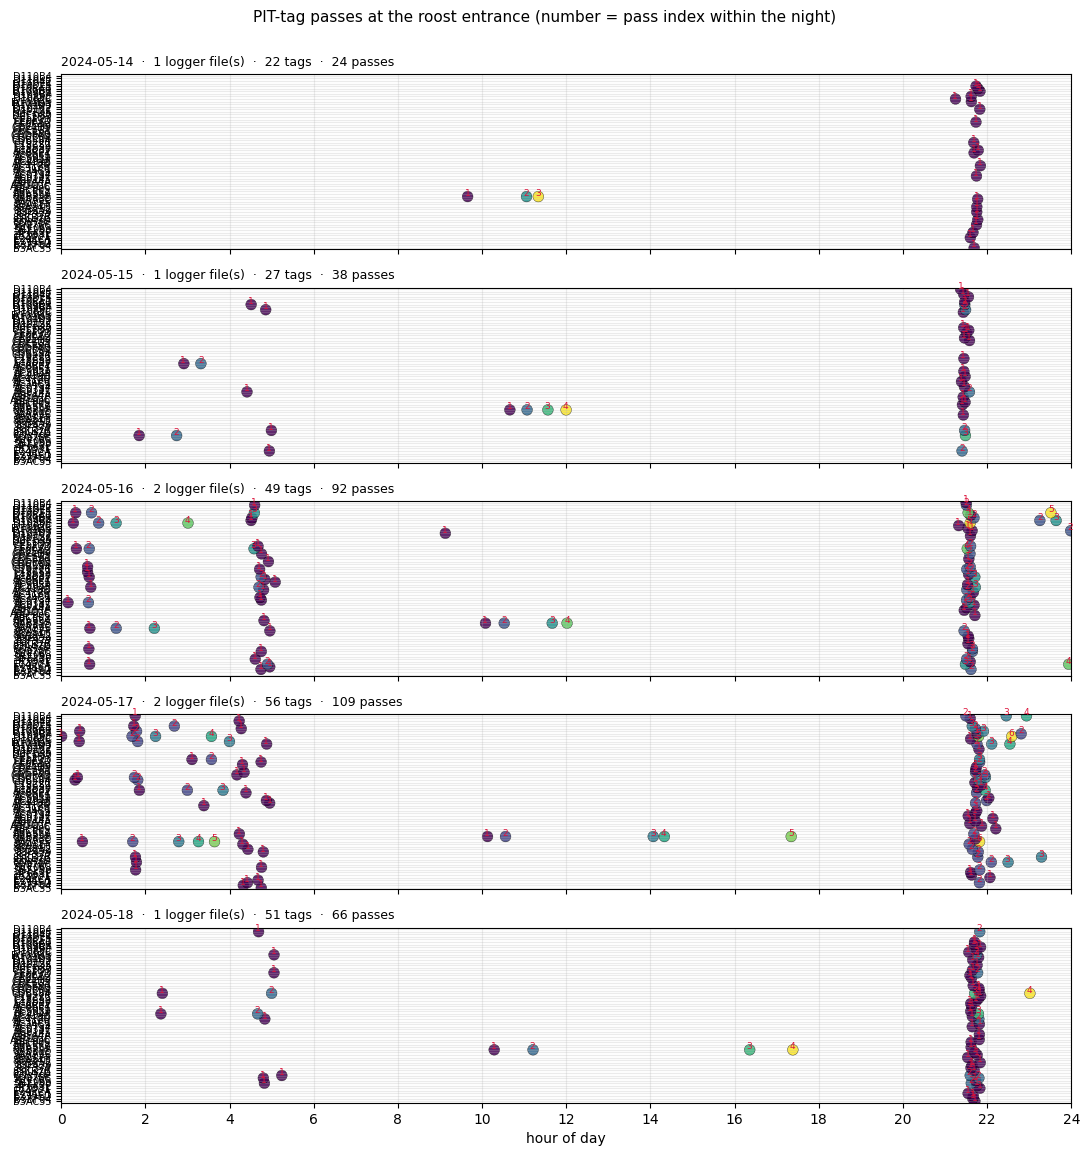

In [4]:
nights = sorted(passes.date.unique())
tags = sorted(passes.tag.unique())
lut = {t: i for i, t in enumerate(tags)}

fig, axes = plt.subplots(len(nights), 1, figsize=(11, 2.3 * len(nights)), sharex=True, squeeze=False)
for ax, night in zip(axes[:, 0], nights):
    sub = passes[passes.date == night]
    x = sub.clock.map(lambda t: t.hour + t.minute / 60 + t.second / 3600)
    y = sub.tag.map(lut)
    sizes = sub.pass_id.map(lambda k: 60)
    ax.scatter(x, y, s=sizes, c=sub.pass_id, cmap="viridis", alpha=0.85, edgecolor="k", linewidth=0.3)
    for _, r in sub.iterrows():
        ax.text(r.clock.hour + r.clock.minute / 60, lut[r.tag] + 0.22, str(int(r.pass_id)),
                fontsize=6.5, ha="center", color="crimson")
    ax.set_yticks(range(len(tags)), [t[-6:] for t in tags], fontsize=7)
    ax.set_ylim(-0.6, len(tags) - 0.4)
    ax.set_title(f"{pd.Timestamp(night):%Y-%m-%d}  ·  {int(sub.n_files.max())} logger file(s)  ·  {sub.tag.nunique()} tags  ·  {len(sub)} passes",
                 fontsize=9, loc="left")
    ax.grid(alpha=0.25)
    ax.set_xlim(0, 24)
    ax.set_xticks(range(0, 25, 2))
axes[-1, 0].set_xlabel("hour of day")
fig.suptitle("PIT-tag passes at the roost entrance (number = pass index within the night)", y=1.001, fontsize=11)
fig.tight_layout()
plt.show()


## 4. Passes per individual per night — the reproductive-status signal

The paper's classification needs ≥7 days; with 5 nights we cannot classify anything yet.
What we *can* check is whether the nights look unimodal (single evening emergence + morning
return = 2 passes) as expected for **gestation** in mid-May, or already multi-emergence.


passes per tag per night (0 = not detected) — 68 tags x 5 nights


date,2024-05-14,2024-05-15,2024-05-16,2024-05-17,2024-05-18
tag,,,,,
0006B3AC35,1,0,0,1,1
0006B3BF04,0,0,0,1,1
0006E239ED,0,0,2,2,1
0006E241C1,0,0,1,1,1
0006E24ECA,1,2,4,1,0
00071E2D31,0,0,1,1,1
00074F663E,1,0,2,1,1
00075B22B0,0,0,0,2,2
00075CE063,0,0,0,1,1


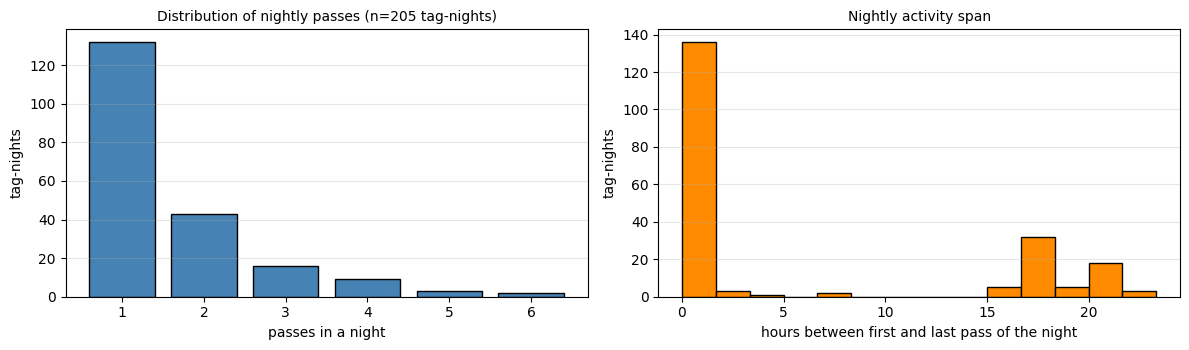


tag-nights by number of passes:
n_passes
1    132
2     43
3     16
4      9
5      3
6      2

night typing:
night_type
incomplete         132
single-bout         43
multi-emergence     30

share of complete-looking single-bout nights (out + back, nothing in between): 0.18
share with mid-night activity (>=1 pass 23:00-03:00)                    : 0.151

per-night overview:


,tags,passes,single_bout,multi,midnight
date,,,,,
2024-05-14,22,24,0,1,0
2024-05-15,27,38,6,2,2
2024-05-16,49,92,16,10,13
2024-05-17,56,109,14,14,14
2024-05-18,51,66,7,3,2


In [5]:
per_night = (passes.groupby(["tag", "date"])
                    .agg(n_passes=("pass_id", "size"),
                         first=("start", "min"), last=("end", "max"))
                    .reset_index())

# a pass in the middle of the night = a return between the dusk exit and the dawn return
mid = (passes.assign(h=passes.clock.map(lambda t: t.hour))
             .query("h >= 23 or h <= 3")
             .groupby(["tag", "date"]).size().rename("n_midnight").reset_index())
per_night = per_night.merge(mid, on=["tag", "date"], how="left").fillna({"n_midnight": 0})
per_night["n_midnight"] = per_night["n_midnight"].astype(int)

# night typing: 1 pass = incomplete log; 2 passes = single bout (out + back); >=3 = candidate multi-emergence
per_night["night_type"] = np.select(
    [per_night.n_passes == 1, per_night.n_passes == 2, per_night.n_passes >= 3],
    ["incomplete", "single-bout", "multi-emergence"], default="?")
per_night["span_h"] = (per_night["last"] - per_night["first"]).dt.total_seconds() / 3600

pivot = per_night.pivot(index="tag", columns="date", values="n_passes").fillna(0).astype(int)
pivot.index.name = "tag"
print(f"passes per tag per night (0 = not detected) — {pivot.shape[0]} tags x {pivot.shape[1]} nights")
display(pivot.head(15))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
ax = axes[0]
counts = per_night.n_passes.value_counts().sort_index()
ax.bar(counts.index, counts.values, color="steelblue", edgecolor="k")
ax.set_xlabel("passes in a night"); ax.set_ylabel("tag-nights")
ax.set_title(f"Distribution of nightly passes (n={len(per_night)} tag-nights)", fontsize=10)
ax.grid(alpha=0.3, axis="y")

ax = axes[1]
ax.hist(per_night.span_h, bins=14, color="darkorange", edgecolor="k")
ax.set_xlabel("hours between first and last pass of the night")
ax.set_ylabel("tag-nights")
ax.set_title("Nightly activity span", fontsize=10)
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
plt.show()

print("\ntag-nights by number of passes:")
print(per_night.n_passes.value_counts().sort_index().rename("tag-nights").to_string())
print("\nnight typing:")
print(per_night.night_type.value_counts().to_string())
print("\nshare of complete-looking single-bout nights (out + back, nothing in between):",
      round(((per_night.n_passes == 2) & (per_night.n_midnight == 0)).mean(), 3))
print("share with mid-night activity (>=1 pass 23:00-03:00)                    :",
      round((per_night.n_midnight > 0).mean(), 3))

print("\nper-night overview:")
night_ov = passes.groupby("date").agg(tags=("tag", "nunique"), passes=("pass_id", "size"))
sub = per_night.groupby("date")
night_ov["single_bout"] = sub.apply(lambda g: int((g.night_type == "single-bout").sum()))
night_ov["multi"] = sub.apply(lambda g: int((g.night_type == "multi-emergence").sum()))
night_ov["midnight"] = sub.apply(lambda g: int((g.n_midnight > 0).sum()))
display(night_ov)


## 5. Read-out, caveats and open questions

Printed below rather than asserted: the dataset is 5 nights of a pilot, so everything here is
**descriptive**. Nothing in this notebook infers reproductive status yet.


In [6]:
summary = (per_night.groupby("tag")
                    .agg(nights=("date", "nunique"), total_passes=("n_passes", "sum"),
                         mean_passes=("n_passes", "mean"), max_passes=("n_passes", "max"))
                    .sort_values(["nights", "total_passes"], ascending=False).round(2))
display(summary)

print("SITE / LOGGER LAYOUT")
display(night_meta[["date", "source_file", "box", "lid", "state", "delim", "detections"]])

morning = raw[raw.ts.dt.hour.between(8, 11)]
print("\nDaytime detections (08:00-12:00):", len(morning), "from", morning.tag.nunique(), "tags")
display(morning.tag.value_counts().head(5))

print("\nOPEN QUESTIONS FOR ANUAR")
for q in [
    "What is the `state` flag — empty vs TQ? (box occupied vs transponder-equipped logger?)",
    "K<box> = Kasten (bat box) number, LID = logger/antenna id? What is site GB2?",
    "Is `Mbec` Myotis bechsteinii? Then this is a European colony, not the Canadian paper site.",
    "Is tag 00079ABB95 a stationary/reference tag at the entrance? It fires every morning ~09:30-11:30.",
    "Where is the rest of the season (paper needs June-July: gestation -> lactation transition)?",
    "Do we want the full field sheet (tag -> sex/reproductive state per individual) for validation?",
]: print(" -", q)


,nights,total_passes,mean_passes,max_passes
tag,,,,
00079ABB95,5,20,4.0,5
0007D1088C,5,15,3.0,6
0007ACAC37,5,11,2.2,4
0007D109BB,5,9,1.8,3
0007D10BA0,5,6,1.2,2
...,...,...,...,...
0007AC80F1,1,1,1.0,1
0007CDEE51,1,1,1.0,1
0007D0ED80,1,1,1.0,1


SITE / LOGGER LAYOUT


,date,source_file,box,lid,state,delim,detections
0,2024-05-14,20240514_GB2_K46_LID31_Mbec_empty.csv,46,31,empty,;,42
1,2024-05-14,20240514_GB2_K9_LID37_Mbec_empty.csv,9,37,empty,;,10
2,2024-05-15,20240515_GB2_K84_LID37_Mbec_empty.csv,84,37,empty,;,47
3,2024-05-15,20240515_GB2_K89_LID31_Mbec_TQ.csv,89,31,TQ,;,82
4,2024-05-16,20240516_GB2_K37_LID32_Mbec_TQ.csv,37,32,TQ,",",62
5,2024-05-16,20240516_GB2_K81_LID37_Mbec_TQ.csv,81,37,TQ,;,48
6,2024-05-16,20240516_GB2_K89_LID31_Mbec_TQ.csv,89,31,TQ,",",131
7,2024-05-17,20240517_GB2_K37_LID32_Mbec_empty.csv,37,32,empty,;,48
8,2024-05-17,20240517_GB2_K81_LID37_Mbec_TQ.csv,81,37,TQ,;,58
9,2024-05-17,20240517_GB2_K89_LID31_Mbec_TQ.csv,89,31,TQ,;,160



Daytime detections (08:00-12:00): 40 from 2 tags


tag
00079ABB95    39
0007D10482     1
Name: count, dtype: int64


OPEN QUESTIONS FOR ANUAR
 - What is the `state` flag — empty vs TQ? (box occupied vs transponder-equipped logger?)
 - K<box> = Kasten (bat box) number, LID = logger/antenna id? What is site GB2?
 - Is `Mbec` Myotis bechsteinii? Then this is a European colony, not the Canadian paper site.
 - Is tag 00079ABB95 a stationary/reference tag at the entrance? It fires every morning ~09:30-11:30.
 - Where is the rest of the season (paper needs June-July: gestation -> lactation transition)?
 - Do we want the full field sheet (tag -> sex/reproductive state per individual) for validation?
